In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})

DATA = '../data/raw/'
PROC = '../data/processed/'
FIG  = '../paper/figures/'
os.makedirs(PROC, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
t0 = time.time()

train_labels = pd.read_csv(DATA + 'Train-1542865627584.csv')
train_bene   = pd.read_csv(DATA + 'Train_Beneficiarydata-1542865627584.csv')
train_inp    = pd.read_csv(DATA + 'Train_Inpatientdata-1542865627584.csv')
train_outp   = pd.read_csv(DATA + 'Train_Outpatientdata-1542865627584.csv')
test_labels  = pd.read_csv(DATA + 'Test-1542969243754.csv')
test_bene    = pd.read_csv(DATA + 'Test_Beneficiarydata-1542969243754.csv')
test_inp     = pd.read_csv(DATA + 'Test_Inpatientdata-1542969243754.csv')
test_outp    = pd.read_csv(DATA + 'Test_Outpatientdata-1542969243754.csv')

print(f"All files loaded in {time.time()-t0:.2f}s")

# Encode target immediately
train_labels['Label'] = (train_labels['PotentialFraud'] == 'Yes').astype(int)
print(f"Target encoded: 1=Fraud ({train_labels['Label'].sum()}), 0=Non-fraud ({(train_labels['Label']==0).sum()})")

All files loaded in 6.47s
Target encoded: 1=Fraud (506), 0=Non-fraud (4904)


In [3]:
t_bene = time.time()

def process_beneficiary(bene_df):
    df = bene_df.copy()

    # Date features
    df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
    df['DOD'] = pd.to_datetime(df['DOD'], errors='coerce')
    ref        = pd.Timestamp('2009-12-01')
    df['Age']    = ((ref - df['DOB']).dt.days / 365.25).clip(lower=0)
    df['IsDead'] = df['DOD'].notna().astype(int)

    # ChronicCond fix: 1=Yes→1, 2=No→0
    chronic_cols = [c for c in df.columns if 'ChronicCond' in c]
    for col in chronic_cols:
        df[col] = (df[col] == 1).astype(int)
    df['NumChronicConditions'] = df[chronic_cols].sum(axis=1)

    # RenalDiseaseIndicator: Y/0 → 1/0
    df['RenalDisease'] = (df['RenalDiseaseIndicator'] == 'Y').astype(int)

    # Gender: make 0/1 binary
    df['GenderBinary'] = (df['Gender'] == 1).astype(int)

    # Keep only what we need for aggregation
    keep = ['BeneID','Age','IsDead','NumChronicConditions','RenalDisease',
            'GenderBinary','IPAnnualReimbursementAmt','IPAnnualDeductibleAmt',
            'OPAnnualReimbursementAmt','OPAnnualDeductibleAmt'] + chronic_cols
    return df[[c for c in keep if c in df.columns]]

train_bene_proc = process_beneficiary(train_bene)
test_bene_proc  = process_beneficiary(test_bene)

print(f"Beneficiary processed in {time.time()-t_bene:.3f}s")
print(f"Train beneficiary shape: {train_bene_proc.shape}")
print(f"\nSample:")
print(train_bene_proc.head(2).to_string())

Beneficiary processed in 0.364s
Train beneficiary shape: (138556, 21)

Sample:
      BeneID        Age  IsDead  NumChronicConditions  RenalDisease  GenderBinary  IPAnnualReimbursementAmt  IPAnnualDeductibleAmt  OPAnnualReimbursementAmt  OPAnnualDeductibleAmt  ChronicCond_Alzheimer  ChronicCond_Heartfailure  ChronicCond_KidneyDisease  ChronicCond_Cancer  ChronicCond_ObstrPulmonary  ChronicCond_Depression  ChronicCond_Diabetes  ChronicCond_IschemicHeart  ChronicCond_Osteoporasis  ChronicCond_rheumatoidarthritis  ChronicCond_stroke
0  BENE11001  66.915811       0                     7             0             1                     36000                   3204                        60                     70                      1                         0                          1                   0                           0                       1                     1                          1                         0                                1                   1
1  BENE11

In [4]:
t_inp = time.time()

def process_inpatient(inp_df, bene_proc):
    df = inp_df.copy()

    # Parse dates
    for col in ['ClaimStartDt','ClaimEndDt','AdmissionDt','DischargeDt']:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # Duration features
    df['StayDuration']  = (df['DischargeDt'] - df['AdmissionDt']).dt.days.clip(lower=0)
    df['ClaimDuration'] = (df['ClaimEndDt']  - df['ClaimStartDt']).dt.days.clip(lower=0)

    # Diagnosis code count per claim (non-null diagnosis columns)
    diag_cols = [c for c in df.columns if 'ClmDiagnosisCode' in c]
    df['NumDiagnosisCodes'] = df[diag_cols].notna().sum(axis=1)

    # Procedure code count per claim
    proc_cols = [c for c in df.columns if 'ClmProcedureCode' in c]
    df['NumProcedureCodes'] = df[proc_cols].notna().sum(axis=1)

    # Merge with beneficiary features
    df = df.merge(bene_proc, on='BeneID', how='left')

    # Provider-level aggregation — THIS IS THE CORE
    agg = df.groupby('Provider').agg(
        # Volume features
        IP_NumClaims             = ('ClaimID',                'count'),
        IP_NumUniqueBeneficiaries= ('BeneID',                 'nunique'),
        IP_NumUniqueAttPhysicians= ('AttendingPhysician',     'nunique'),
        IP_NumUniqueOpPhysicians = ('OperatingPhysician',     'nunique'),
        IP_NumUniqueOthPhysicians= ('OtherPhysician',         'nunique'),

        # Financial features
        IP_TotalClaimAmt         = ('InscClaimAmtReimbursed', 'sum'),
        IP_AvgClaimAmt           = ('InscClaimAmtReimbursed', 'mean'),
        IP_MaxClaimAmt           = ('InscClaimAmtReimbursed', 'max'),
        IP_StdClaimAmt           = ('InscClaimAmtReimbursed', 'std'),
        IP_TotalDeductible       = ('DeductibleAmtPaid',      'sum'),
        IP_AvgDeductible         = ('DeductibleAmtPaid',      'mean'),

        # Duration features
        IP_AvgStayDuration       = ('StayDuration',           'mean'),
        IP_MaxStayDuration       = ('StayDuration',           'max'),
        IP_TotalStayDays         = ('StayDuration',           'sum'),
        IP_AvgClaimDuration      = ('ClaimDuration',          'mean'),

        # Diagnosis/procedure complexity
        IP_AvgDiagnosisCodes     = ('NumDiagnosisCodes',      'mean'),
        IP_AvgProcedureCodes     = ('NumProcedureCodes',      'mean'),

        # Patient demographic features
        IP_AvgPatientAge         = ('Age',                    'mean'),
        IP_PctDeadPatients       = ('IsDead',                 'mean'),
        IP_AvgChronicConditions  = ('NumChronicConditions',   'mean'),
        IP_PctRenalDisease       = ('RenalDisease',           'mean'),
        IP_AvgGender             = ('GenderBinary',           'mean'),

        # Reimbursement from beneficiary annual data
        IP_AvgIPAnnualReimb      = ('IPAnnualReimbursementAmt','mean'),
        IP_AvgOPAnnualReimb      = ('OPAnnualReimbursementAmt','mean'),
    ).reset_index()

    # Fill std NaN (providers with 1 claim have no std)
    agg['IP_StdClaimAmt'] = agg['IP_StdClaimAmt'].fillna(0)

    return agg

train_inp_agg = process_inpatient(train_inp, train_bene_proc)
test_inp_agg  = process_inpatient(test_inp,  test_bene_proc)

print(f"Inpatient aggregated in {time.time()-t_inp:.3f}s")
print(f"Train inpatient provider features shape: {train_inp_agg.shape}")
print(f"Columns: {train_inp_agg.columns.tolist()}")

Inpatient aggregated in 0.636s
Train inpatient provider features shape: (2092, 25)
Columns: ['Provider', 'IP_NumClaims', 'IP_NumUniqueBeneficiaries', 'IP_NumUniqueAttPhysicians', 'IP_NumUniqueOpPhysicians', 'IP_NumUniqueOthPhysicians', 'IP_TotalClaimAmt', 'IP_AvgClaimAmt', 'IP_MaxClaimAmt', 'IP_StdClaimAmt', 'IP_TotalDeductible', 'IP_AvgDeductible', 'IP_AvgStayDuration', 'IP_MaxStayDuration', 'IP_TotalStayDays', 'IP_AvgClaimDuration', 'IP_AvgDiagnosisCodes', 'IP_AvgProcedureCodes', 'IP_AvgPatientAge', 'IP_PctDeadPatients', 'IP_AvgChronicConditions', 'IP_PctRenalDisease', 'IP_AvgGender', 'IP_AvgIPAnnualReimb', 'IP_AvgOPAnnualReimb']


In [5]:
t_outp = time.time()

def process_outpatient(outp_df, bene_proc):
    df = outp_df.copy()

    # Parse dates — NO AdmissionDt/DischargeDt in outpatient
    for col in ['ClaimStartDt','ClaimEndDt']:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['ClaimDuration'] = (df['ClaimEndDt'] - df['ClaimStartDt']).dt.days.clip(lower=0)

    diag_cols = [c for c in df.columns if 'ClmDiagnosisCode' in c]
    df['NumDiagnosisCodes'] = df[diag_cols].notna().sum(axis=1)

    df = df.merge(bene_proc, on='BeneID', how='left')

    agg = df.groupby('Provider').agg(
        OP_NumClaims             = ('ClaimID',                'count'),
        OP_NumUniqueBeneficiaries= ('BeneID',                 'nunique'),
        OP_NumUniqueAttPhysicians= ('AttendingPhysician',     'nunique'),
        OP_TotalClaimAmt         = ('InscClaimAmtReimbursed', 'sum'),
        OP_AvgClaimAmt           = ('InscClaimAmtReimbursed', 'mean'),
        OP_MaxClaimAmt           = ('InscClaimAmtReimbursed', 'max'),
        OP_StdClaimAmt           = ('InscClaimAmtReimbursed', 'std'),
        OP_TotalDeductible       = ('DeductibleAmtPaid',      'sum'),
        OP_AvgClaimDuration      = ('ClaimDuration',          'mean'),
        OP_AvgDiagnosisCodes     = ('NumDiagnosisCodes',      'mean'),
        OP_AvgPatientAge         = ('Age',                    'mean'),
        OP_PctDeadPatients       = ('IsDead',                 'mean'),
        OP_AvgChronicConditions  = ('NumChronicConditions',   'mean'),
    ).reset_index()

    agg['OP_StdClaimAmt'] = agg['OP_StdClaimAmt'].fillna(0)

    return agg

train_outp_agg = process_outpatient(train_outp, train_bene_proc)
test_outp_agg  = process_outpatient(test_outp,  test_bene_proc)

print(f"Outpatient aggregated in {time.time()-t_outp:.3f}s")
print(f"Train outpatient provider features shape: {train_outp_agg.shape}")

Outpatient aggregated in 2.778s
Train outpatient provider features shape: (5012, 14)


In [6]:
t_merge = time.time()

def build_master(labels_df, inp_agg, outp_agg):
    # Start with all labeled providers
    df = labels_df[['Provider']].copy()
    if 'Label' in labels_df.columns:
        df['Label'] = labels_df['Label'].values

    # Merge inpatient and outpatient aggregations
    df = df.merge(inp_agg,  on='Provider', how='left')
    df = df.merge(outp_agg, on='Provider', how='left')

    # Fill missing with 0 — provider had no claims of that type
    df = df.fillna(0)

    # ── ADVANCED ENGINEERED FEATURES (mentor point 5 — LR justification) ──

    # Ratio: inpatient vs outpatient claims
    # High ratio = provider bills more inpatient (pays more → fraud signal)
    df['IP_OP_ClaimRatio']    = df['IP_NumClaims'] / (df['OP_NumClaims'] + 1)

    # Claims per unique patient — high = billing many procedures per patient
    df['IP_ClaimsPerPatient'] = df['IP_NumClaims'] / (df['IP_NumUniqueBeneficiaries'] + 1)
    df['OP_ClaimsPerPatient'] = df['OP_NumClaims'] / (df['OP_NumUniqueBeneficiaries'] + 1)

    # Physician concentration — few physicians for many patients = suspicious
    df['IP_PatientsPerPhysician'] = df['IP_NumUniqueBeneficiaries'] / (df['IP_NumUniqueAttPhysicians'] + 1)
    df['OP_PatientsPerPhysician'] = df['OP_NumUniqueBeneficiaries'] / (df['OP_NumUniqueAttPhysicians'] + 1)

    # Claim amount per day — high daily billing rate = suspicious
    df['IP_ClaimAmtPerStayDay']   = df['IP_TotalClaimAmt'] / (df['IP_TotalStayDays'] + 1)

    # Total financial exposure
    df['Total_ClaimAmt']          = df['IP_TotalClaimAmt'] + df['OP_TotalClaimAmt']
    df['Total_Deductible']        = df['IP_TotalDeductible'] + df['OP_TotalDeductible']

    # Combined patient volume
    df['Total_UniqueBeneficiaries'] = df['IP_NumUniqueBeneficiaries'] + df['OP_NumUniqueBeneficiaries']

    # Diagnosis complexity ratio (inpatient vs outpatient)
    df['DiagComplexityRatio']     = df['IP_AvgDiagnosisCodes'] / (df['OP_AvgDiagnosisCodes'] + 1)

    return df

train_master = build_master(train_labels, train_inp_agg, train_outp_agg)
test_master  = build_master(test_labels,  test_inp_agg,  test_outp_agg)

merge_time = time.time() - t_merge
print(f"Master dataset built in {merge_time:.3f}s")
print(f"Train master shape: {train_master.shape}")
print(f"Test  master shape: {test_master.shape}")
print(f"\nFeature columns ({train_master.shape[1]-2} total features):")
feat_cols = [c for c in train_master.columns if c not in ['Provider','Label']]
for i, c in enumerate(feat_cols, 1):
    print(f"  {i:>2}. {c}")

Master dataset built in 0.172s
Train master shape: (5410, 49)
Test  master shape: (1353, 48)

Feature columns (47 total features):
   1. IP_NumClaims
   2. IP_NumUniqueBeneficiaries
   3. IP_NumUniqueAttPhysicians
   4. IP_NumUniqueOpPhysicians
   5. IP_NumUniqueOthPhysicians
   6. IP_TotalClaimAmt
   7. IP_AvgClaimAmt
   8. IP_MaxClaimAmt
   9. IP_StdClaimAmt
  10. IP_TotalDeductible
  11. IP_AvgDeductible
  12. IP_AvgStayDuration
  13. IP_MaxStayDuration
  14. IP_TotalStayDays
  15. IP_AvgClaimDuration
  16. IP_AvgDiagnosisCodes
  17. IP_AvgProcedureCodes
  18. IP_AvgPatientAge
  19. IP_PctDeadPatients
  20. IP_AvgChronicConditions
  21. IP_PctRenalDisease
  22. IP_AvgGender
  23. IP_AvgIPAnnualReimb
  24. IP_AvgOPAnnualReimb
  25. OP_NumClaims
  26. OP_NumUniqueBeneficiaries
  27. OP_NumUniqueAttPhysicians
  28. OP_TotalClaimAmt
  29. OP_AvgClaimAmt
  30. OP_MaxClaimAmt
  31. OP_StdClaimAmt
  32. OP_TotalDeductible
  33. OP_AvgClaimDuration
  34. OP_AvgDiagnosisCodes
  35. OP_AvgPat

In [7]:
print("=" * 55)
print("DATA QUALITY CHECK")
print("=" * 55)

print(f"\nMissing values in train master: {train_master.isnull().sum().sum()}")
print(f"Missing values in test master:  {test_master.isnull().sum().sum()}")
print(f"Infinite values in train:       {np.isinf(train_master.select_dtypes(include=np.number)).sum().sum()}")

# Replace any infinities that crept in from divisions
train_master.replace([np.inf, -np.inf], 0, inplace=True)
test_master.replace([np.inf, -np.inf],  0, inplace=True)

print(f"After fix — infinite values:    {np.isinf(train_master.select_dtypes(include=np.number)).sum().sum()}")

print(f"\nLabel distribution in train master:")
print(train_master['Label'].value_counts())
print(f"Fraud rate: {train_master['Label'].mean()*100:.2f}%")

DATA QUALITY CHECK

Missing values in train master: 0
Missing values in test master:  0
Infinite values in train:       0
After fix — infinite values:    0

Label distribution in train master:
Label
0    4904
1     506
Name: count, dtype: int64
Fraud rate: 9.35%


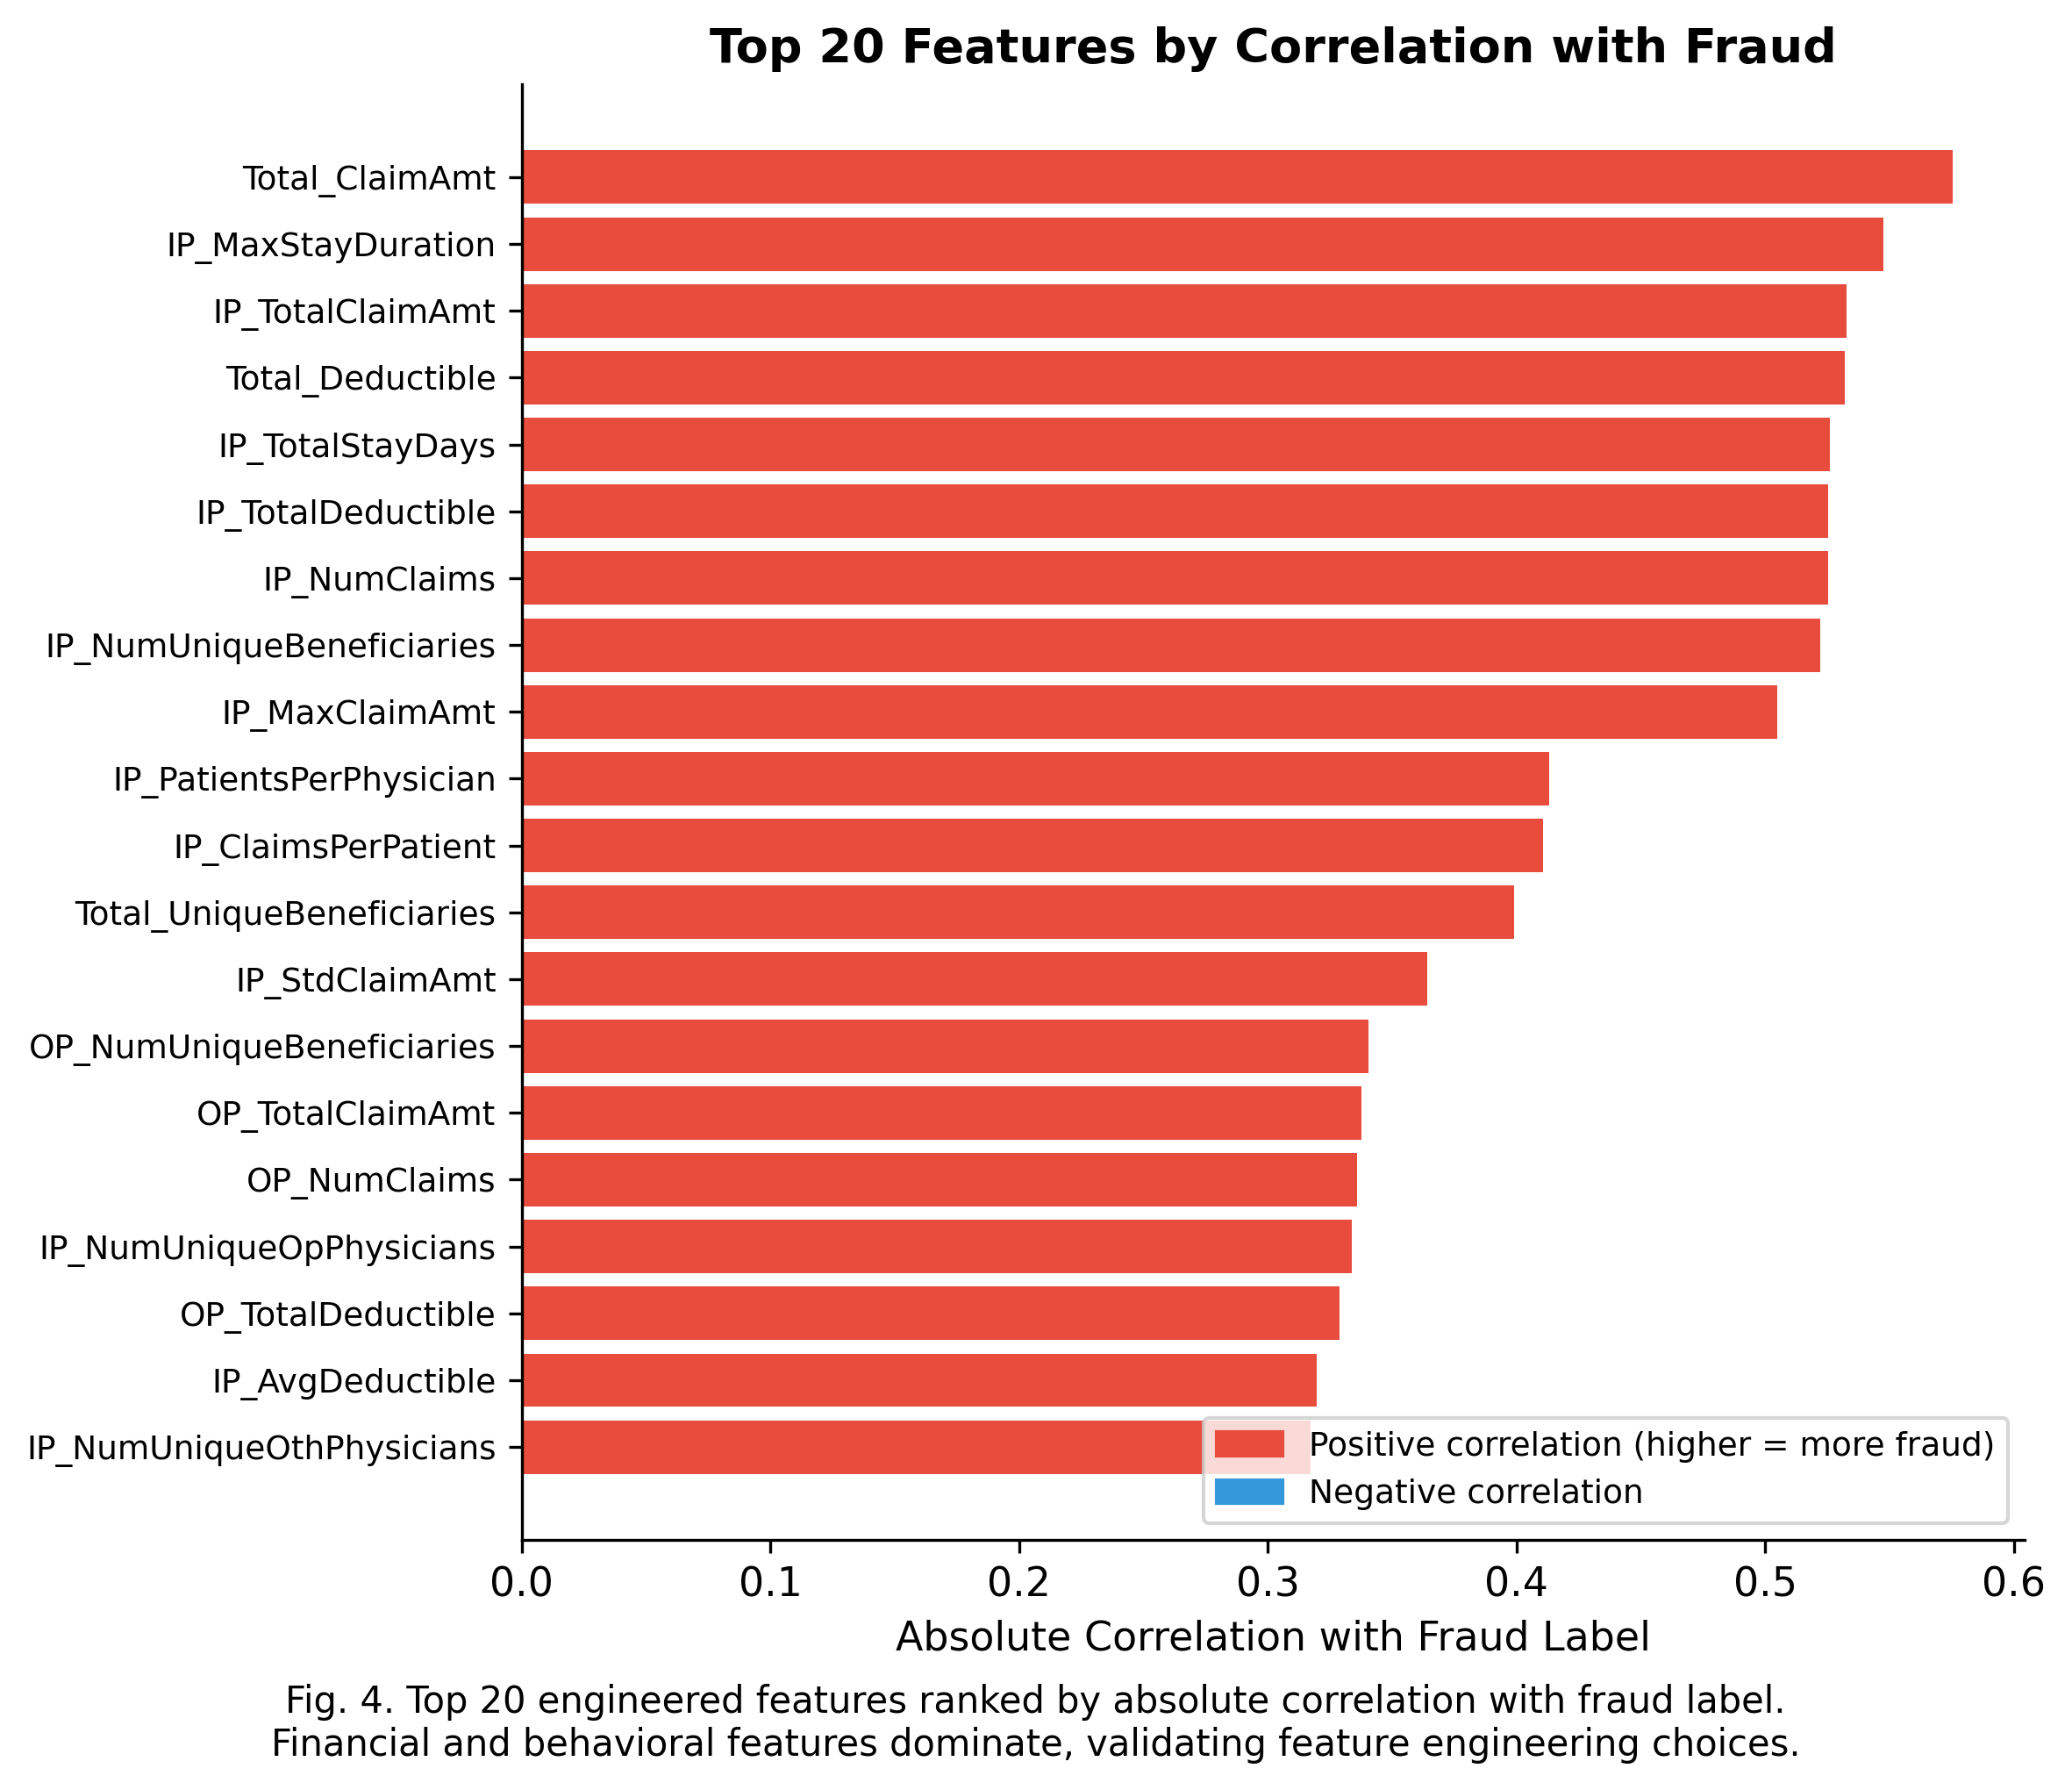

Top 10 features correlated with fraud:
  Total_ClaimAmt                          : 0.5756  (↑ fraud)
  IP_MaxStayDuration                      : 0.5477  (↑ fraud)
  IP_TotalClaimAmt                        : 0.5328  (↑ fraud)
  Total_Deductible                        : 0.5321  (↑ fraud)
  IP_TotalStayDays                        : 0.5260  (↑ fraud)
  IP_TotalDeductible                      : 0.5255  (↑ fraud)
  IP_NumClaims                            : 0.5254  (↑ fraud)
  IP_NumUniqueBeneficiaries               : 0.5223  (↑ fraud)
  IP_MaxClaimAmt                          : 0.5049  (↑ fraud)
  IP_PatientsPerPhysician                 : 0.4134  (↑ fraud)

Saved: ../paper/figures/fig04_feature_correlation.png


In [8]:
feat_cols = [c for c in train_master.columns if c not in ['Provider','Label']]

# Correlation of each feature with fraud label
corr = train_master[feat_cols + ['Label']].corr()['Label'].drop('Label')
corr_sorted = corr.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e74c3c' if corr[f] > 0 else '#3498db' for f in corr_sorted.index]
ax.barh(range(len(corr_sorted)), corr_sorted.values, color=colors)
ax.set_yticks(range(len(corr_sorted)))
ax.set_yticklabels(corr_sorted.index, fontsize=9)
ax.set_xlabel('Absolute Correlation with Fraud Label')
ax.set_title('Top 20 Features by Correlation with Fraud')
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#e74c3c', label='Positive correlation (higher = more fraud)'),
    Patch(color='#3498db', label='Negative correlation'),
], fontsize=9, loc='lower right')

fig.suptitle(
    'Fig. 4. Top 20 engineered features ranked by absolute correlation with fraud label.\n'
    'Financial and behavioral features dominate, validating feature engineering choices.',
    fontsize=10, y=0.01
)
plt.tight_layout()
plt.savefig(FIG + 'fig04_feature_correlation.png')
plt.show()

print("Top 10 features correlated with fraud:")
for feat, val in corr_sorted.head(10).items():
    direction = "↑ fraud" if corr[feat] > 0 else "↓ fraud"
    print(f"  {feat:<40}: {val:.4f}  ({direction})")

print(f"\nSaved: {FIG}fig04_feature_correlation.png")

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from imblearn.over_sampling  import SMOTE

feat_cols = [c for c in train_master.columns if c not in ['Provider','Label']]
X = train_master[feat_cols].values
y = train_master['Label'].values

# Step 1 — Split FIRST, before SMOTE
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape[0]} samples  (Fraud: {y_train.sum()}, Clean: {(y_train==0).sum()})")
print(f"Val set:   {X_val.shape[0]} samples   (Fraud: {y_val.sum()},  Clean: {(y_val==0).sum()})")

# Step 2 — Scale BEFORE SMOTE (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f"\nScaler fitted on train only. Features: {scaler.n_features_in_}")

# Step 3 — SMOTE on train only
t_smote = time.time()
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
smote_time = time.time() - t_smote

print(f"\nAfter SMOTE:")
print(f"  X_train_res shape: {X_train_res.shape}")
print(f"  Fraud samples:     {y_train_res.sum()}")
print(f"  Non-fraud samples: {(y_train_res==0).sum()}")
print(f"  SMOTE time:        {smote_time:.3f}s")
print(f"\nValidation set remains UNCHANGED (original distribution):")
print(f"  Fraud: {y_val.sum()}, Non-fraud: {(y_val==0).sum()}")

# Prepare test set
X_test = test_master[feat_cols].values
X_test_scaled = scaler.transform(X_test)

Train set: 4328 samples  (Fraud: 405, Clean: 3923)
Val set:   1082 samples   (Fraud: 101,  Clean: 981)

Scaler fitted on train only. Features: 47

After SMOTE:
  X_train_res shape: (7846, 47)
  Fraud samples:     3923
  Non-fraud samples: 3923
  SMOTE time:        4.597s

Validation set remains UNCHANGED (original distribution):
  Fraud: 101, Non-fraud: 981


In [10]:
import joblib

t_save = time.time()

# Save processed master datasets
train_master.to_csv(PROC + 'train_master.csv', index=False)
test_master.to_csv(PROC + 'test_master.csv',   index=False)

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Save numpy arrays for Phase 3
np.save(PROC + 'X_train_res.npy',   X_train_res)
np.save(PROC + 'y_train_res.npy',   y_train_res)
np.save(PROC + 'X_val_scaled.npy',  X_val_scaled)
np.save(PROC + 'y_val.npy',         y_val)
np.save(PROC + 'X_test_scaled.npy', X_test_scaled)

# Save feature names list
pd.Series(feat_cols).to_csv(PROC + 'feature_names.csv', index=False, header=False)

save_time = time.time() - t_save

print(f"All files saved in {save_time:.3f}s")
print()
print("Files saved to data/processed/:")
for f in sorted(os.listdir(PROC)):
    size = os.path.getsize(PROC + f) / 1024
    print(f"  {f:<30} {size:>8.1f} KB")

print()
print("Model file saved to models/:")
print(f"  scaler.pkl")
print()
print("=" * 55)
print("PHASE 2 COMPLETE")
print("=" * 55)
print(f"Total features engineered: {len(feat_cols)}")
print(f"Train samples after SMOTE: {X_train_res.shape[0]}")
print(f"Validation samples:        {X_val_scaled.shape[0]}")
print(f"Test samples:              {X_test_scaled.shape[0]}")

All files saved in 0.500s

Files saved to data/processed/:
  X_test_scaled.npy                 496.9 KB
  X_train_res.npy                  2881.1 KB
  X_val_scaled.npy                  397.4 KB
  feature_names.csv                   0.9 KB
  test_master.csv                   481.5 KB
  train_master.csv                 1927.1 KB
  y_train_res.npy                    30.8 KB
  y_val.npy                           4.4 KB

Model file saved to models/:
  scaler.pkl

PHASE 2 COMPLETE
Total features engineered: 47
Train samples after SMOTE: 7846
Validation samples:        1082
Test samples:              1353
